### Análise Exploratória dos Dados

Nesta etapa, será realizada uma análise exploratória do dataset com foco nas variáveis **HAS_DISPLAY** e **TOTAL_UNITS**, que representam, respectivamente, a participação dos produtos em ações promocionais do tipo *display* e a quantidade total de unidades vendidas. Como essas variáveis estão diretamente relacionadas à questão de pesquisa e às hipóteses propostas, sua exploração inicial é fundamental para compreender a distribuição dos dados, identificar possíveis desequilíbrios entre os grupos e obter uma visão preliminar do comportamento das vendas.

Além disso, a análise exploratória permitirá verificar características importantes do conjunto de dados, como frequência das observações, medidas descritivas e padrões de distribuição, fornecendo subsídios para a escolha e aplicação dos testes estatísticos nas etapas seguintes.

In [8]:
# Imports e carregamento do dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/df_analytical.csv")

> **Documentação do dataset:** Para uma descrição completa da base analítica, incluindo sua caracterização, origem dos atributos e dicionário de dados, consulte `./docs/dataset_description.md`.

In [9]:
print(df.shape)

df.head(5)

(61079, 28)


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,SIZE_VALUE,SIZE_UNIT,TOTAL_UNITS,...,N_CAMPAIGNS,HAS_COUPON,N_PROMOTION_WEEKS,N_STORES_PROMOTION,DISPLAY_EVENTS,MAILER_EVENTS,DISPLAY_TYPES,MAILER_TYPES,HAS_DISPLAY,HAS_MAILER
0,25671,2,GROCERY,NATIONAL,FRZN ICE,ICE - CRUSHED/CUBED,22 LB,22.0,LB,6.0,...,2,1,0,0,0,0,0,0,0,0
1,26190,69,GROCERY,PRIVATE,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ,50.0,OZ,1.0,...,3,1,5,108,26,108,4,1,1,1
2,26355,69,GROCERY,PRIVATE,COOKIES/CONES,SPECIALTY COOKIES,14 OZ,14.0,OZ,2.0,...,0,0,29,111,1083,0,9,0,1,0
3,26426,69,GROCERY,PRIVATE,SPICES & EXTRACTS,SPICES & SEASONINGS,2.5 OZ,2.5,OZ,1.0,...,0,0,9,107,1,695,1,1,1,1
4,26540,69,GROCERY,PRIVATE,COOKIES/CONES,TRAY PACK/CHOC CHIP COOKIES,16 OZ,16.0,OZ,3.0,...,0,0,75,19,191,0,9,0,1,0


##### Caracterização da variável ``HAS_DISPLAY``

In [10]:
# Informações gerais

print("Tipo da variável:")
print(df["HAS_DISPLAY"].dtype)

print("\nValores únicos:")
print(df["HAS_DISPLAY"].unique())

print("\nValores ausentes:")
print(df["HAS_DISPLAY"].isna().sum())

Tipo da variável:
int64

Valores únicos:
[0 1]

Valores ausentes:
0


##### Distribuição dos grupos

In [11]:
# Quantidade de ocorrências

contagem = df["HAS_DISPLAY"].value_counts().sort_index()
percentual = df["HAS_DISPLAY"].value_counts(normalize=True).sort_index() * 100

resumo = pd.DataFrame({
    "Quantidade": contagem,
    "Percentual (%)": percentual.round(2)
})

print(resumo)

             Quantidade  Percentual (%)
HAS_DISPLAY                            
0                 13606           22.28
1                 47473           77.72


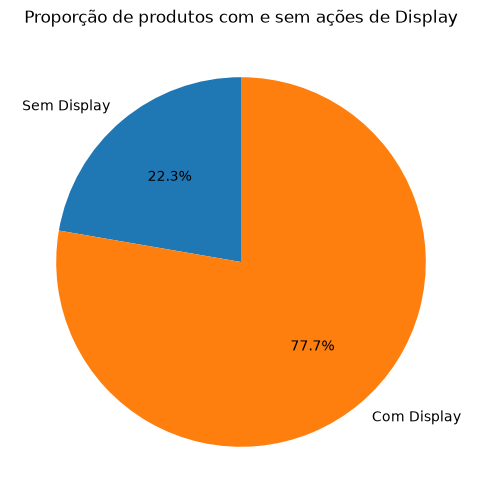

In [13]:
# Gráfico de pizza

plt.figure(figsize=(6,6))

labels = [
    "Sem Display",
    "Com Display"
]

plt.pie(
    contagem,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Proporção de produtos com e sem ações de Display")

plt.show()

##### Comparação preliminar entre os grupos
* com base na variável `TOTAL_UNITS`, que é a variável resposta

In [14]:
df.groupby("HAS_DISPLAY")["TOTAL_UNITS"].describe()

,count,mean,std,min,25%,50%,75%,max
HAS_DISPLAY,,,,,,,,
0,13606.0,22.144863,318.604466,0.0,1.0,2.0,7.0,30896.0
1,47473.0,52.124239,228.210479,0.0,1.0,5.0,34.0,16976.0


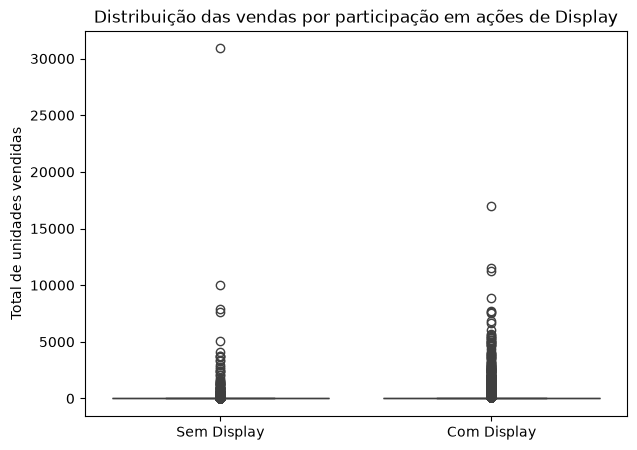

In [ ]:
# Boxplot

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="HAS_DISPLAY",
    y="TOTAL_UNITS"
)

plt.xticks(
    [0,1],
    ["Sem Display","Com Display"]
)

plt.xlabel("")
plt.ylabel("Total de unidades vendidas")

plt.title("Distribuição das vendas por participação em ações de Display")

plt.show()

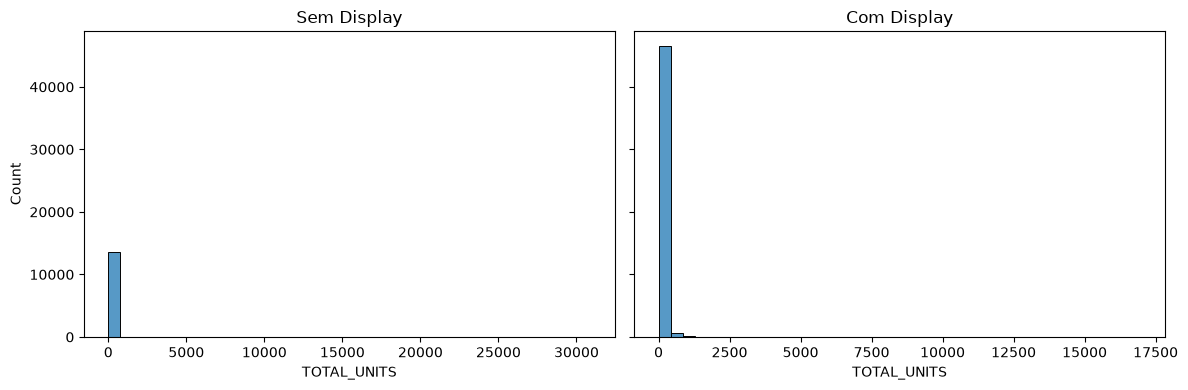

In [ ]:
# Histogramas

fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)

sns.histplot(
    df[df["HAS_DISPLAY"]==0]["TOTAL_UNITS"],
    bins=40,
    ax=ax[0]
)

ax[0].set_title("Sem Display")

sns.histplot(
    df[df["HAS_DISPLAY"]==1]["TOTAL_UNITS"],
    bins=40,
    ax=ax[1]
)

ax[1].set_title("Com Display")

plt.tight_layout()
plt.show()

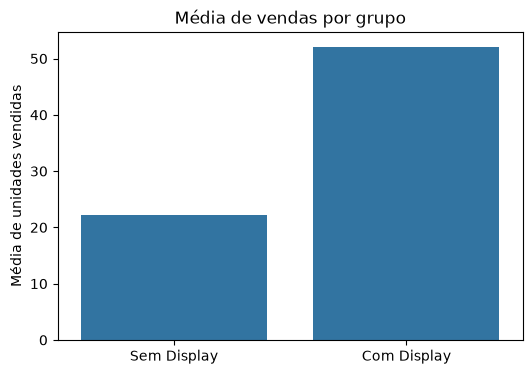

In [18]:
media = (
    df
    .groupby("HAS_DISPLAY")["TOTAL_UNITS"]
    .mean()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=media.index,
    y=media.values
)

plt.xticks(
    [0,1],
    ["Sem Display","Com Display"]
)

plt.ylabel("Média de unidades vendidas")
plt.xlabel("")

plt.title("Média de vendas por grupo")

plt.show()

### Considerações da Análise Exploratória

A análise exploratória mostrou que **77,72%** dos produtos participaram de ações promocionais do tipo *display*, enquanto **22,28%** não participaram. Apesar do desbalanceamento entre os grupos, ambos possuem quantidade suficiente de observações para as análises.

As estatísticas descritivas indicam que produtos com *display* apresentam maior média de unidades vendidas (**52,12**) em comparação aos produtos sem *display* (**22,14**). Além disso, os boxplots e histogramas evidenciam distribuições assimétricas e a presença de diversos valores extremos, características comuns em dados de vendas.

De forma geral, a análise exploratória indica uma diferença descritiva entre os grupos, sugerindo que produtos participantes de ações promocionais do tipo *display* tendem a apresentar maior quantidade média de unidades vendidas.
